In [1]:
import torch
import torch.nn as nn

import torch_geometric as tg
import torch_geometric.utils as tgu
import torch_geometric.nn as tgnn
import matplotlib.pyplot as plt

import numpy as np

In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(DEVICE)

cuda


## Notes from graphcast
 - there are multiple layers of nodes -> some nodes propagate information to more distant nodes
 - loss function takes into account multiple factors - e.g. sample density
 - autoregressive training 
   - model is trained using fix interval
   - to predict more distant (in time) points then previous prediction of a model is used
   - predicting 10 day ahead tends to have large overfitting
 - gnn was selected because weather function is the same in every place of the globe

In [3]:
omega = 1.8

feature_vec_len = 32
x = np.arange(0,6.4,0.1).reshape((-1,1))
t = np.arange(0,6,0.1).reshape([-1,1])

values = np.sin(omega*t+x.T)

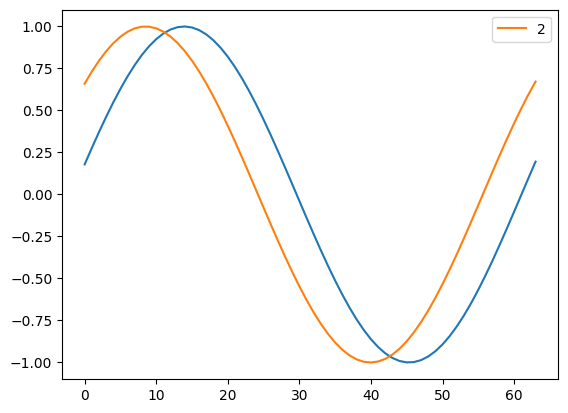

In [4]:
plt.plot(values[1,:])
plt.plot(values[4,:], label='2')
plt.legend()

In [9]:
def get_sample(values, dt=4, inclusion_prob=0.5):
    time_horizon, positions = values.shape

    fully_connected_adj = torch.ones(positions, positions)
    fully_connected = tgu.dense_to_sparse(fully_connected_adj)[0]

    sample = []
    sample_dt = []

    time_stamp = np.random.randint(dt, time_horizon - 2*dt)
    time_to_predict = time_stamp + np.random.randint(1, 2*dt)

    is_included = np.random.random(positions) < inclusion_prob
    for idx, included in zip(range(positions), is_included):
        _time = time_stamp + np.random.randint(-dt, dt)
        sample.append((
            idx/positions,
            included*1.0,
            values[_time, idx] * included,
            _time/64,
            time_to_predict/64,
        ))
        sample_dt.append((
            idx/positions,
            1.0,
            values[time_to_predict, idx],
            time_to_predict/64,
            time_to_predict/64,
        ))

    return tg.data.Data(
        x=torch.tensor(sample, dtype=torch.float32, requires_grad=False),
        edge_index=fully_connected,
        y=torch.tensor(sample_dt, dtype=torch.float32, requires_grad=False)
    )

In [6]:
class AutoEncoder(nn.Module):
    def __init__(self, input_size, hidden_size=8, input_size_expander=4):
        nn.Module.__init__(self)
        
        # Set the number of hidden units
        self.num_hidden = hidden_size
        
        # Define the encoder part of the autoencoder
        self.encoder = nn.Sequential(
            nn.Linear(input_size, input_size_expander*input_size),  # input size: 784, output size: 256
            nn.GELU(),  # apply the ReLU activation function
            nn.Linear(input_size_expander*input_size, self.num_hidden),  # input size: 256, output size: num_hidden
            nn.GELU(),  # apply the ReLU activation function
        )
        
        # Define the decoder part of the autoencoder
        self.decoder = nn.Sequential(
            nn.Linear(self.num_hidden, input_size_expander*input_size),  # input size: num_hidden, output size: 256
            nn.GELU(),  # apply the ReLU activation function
            nn.Linear(input_size_expander*input_size, input_size_expander*input_size),  # input size: num_hidden, output size: 256
            nn.GELU(),  # apply the ReLU activation function
            nn.Linear(input_size_expander*input_size, input_size),  # input size: 256, output size: 784
        )

    def forward(self, x):
        # Pass the input through the encoder
        encoded = self.encoder(x)
        # Pass the encoded representation through the decoder
        decoded = self.decoder(encoded)
        # Return both the encoded representation and the reconstructed output
        return encoded, decoded

In [7]:
class VAE(AutoEncoder):
    def __init__(self, input_size, hidden_size=8, input_size_expander=4):
        AutoEncoder.__init__(self, input_size, hidden_size, input_size_expander)
        # Add mu and log_var layers for reparameterization
        self.mu = nn.Linear(self.num_hidden, self.num_hidden)
        self.log_var = nn.Linear(self.num_hidden, self.num_hidden)

    def reparameterize(self, mu, log_var):
        # Compute the standard deviation from the log variance
        std = torch.exp(0.5 * log_var)
        # Generate random noise using the same shape as std
        eps = torch.randn_like(std)
        # Return the reparameterized sample
        return mu + eps * std

    def forward(self, x):
        # Pass the input through the encoder
        encoded = self.encoder(x)
        # Compute the mean and log variance vectors
        mu = self.mu(encoded)
        log_var = self.log_var(encoded)
        # Reparameterize the latent variable
        z = self.reparameterize(mu, log_var)
        # Pass the latent variable through the decoder
        decoded = self.decoder(z)
        # Return the encoded output, decoded output, mean, and log variance
        return encoded, decoded, mu, log_var

    def sample(self, num_samples):
        with torch.no_grad():
            # Generate random noise
            z = torch.randn(num_samples, self.num_hidden).to(DEVICE)
            # Pass the noise through the decoder to generate samples
            samples = self.decoder(z)
        # Return the generated samples
        return samples

In [8]:
ae = AutoEncoder(3, hidden_size=feature_vec_len,input_size_expander=8)
ae_dataset = torch.cat([get_sample(values).x[:,:3] for _ in range(4096)])
batch_size = 64
num_epochs = 2

optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)

# Define the loss function
criterion = nn.MSELoss()

# Set the device to GPU if available, otherwise use CPU
ae.to(DEVICE)

# Create a DataLoader to handle batching of the training data
train_loader = torch.utils.data.DataLoader(
    ae_dataset, batch_size=64, shuffle=True
)

for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_idx, data in enumerate(train_loader):
        # Get a batch of training data and move it to the device
        data = data.to(DEVICE)

        # Forward pass
        encoded, decoded = ae(data)

        # Compute the loss and perform backpropagation
        loss = criterion(decoded, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update the running loss
        total_loss += loss.item() * data.size(0)

    # Print the epoch loss
    epoch_loss = total_loss / len(train_loader.dataset)
    print(
        "Epoch {}/{}: loss={:.6f}".format(epoch + 1, num_epochs, epoch_loss)
    )

/tmp/ipykernel_1833/610734966.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index=torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


Epoch 1/2: loss=0.006265
Epoch 2/2: loss=0.000003


In [47]:
### VAE NIE DZIAŁĄ

# Define a loss function that combines binary cross-entropy and Kullback-Leibler divergence
def vae_loss_function(recon_x, x, mu, logvar):
    # Compute the binary cross-entropy loss between the reconstructed output and the input data
    BCE = torch.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction="sum")
    # Compute the Kullback-Leibler divergence between the learned latent variable distribution and a standard Gaussian distribution
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    # Combine the two losses by adding them together and return the result
    return BCE + KLD

# Convert the training data to PyTorch tensors
vae_dataset = torch.cat([get_sample(values).x[:,:3] for _ in range(16)])
batch_size = 28
num_epochs = 1

# Create the autoencoder model and optimizer
vae = VAE(3,input_size_expander=8)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

# Define the loss function
criterion = nn.MSELoss(reduction="sum")

# Set the device to GPU if available, otherwise use CPU
vae.to(DEVICE)

# Create a DataLoader to handle batching of the training data
train_loader = torch.utils.data.DataLoader(
    vae_dataset, batch_size=batch_size, shuffle=True
)

# Training loop
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_idx, data in enumerate(train_loader):
        # Get a batch of training data and move it to the device
        data = data.to(DEVICE)

        # Forward pass
        encoded, decoded, mu, log_var = vae(data)

        # Compute the loss and perform backpropagation
        KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        loss = criterion(decoded, data) + 3 * KLD
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update the running loss
        total_loss += loss.item() * data.size(0)

    # Print the epoch loss
    epoch_loss = total_loss / len(train_loader.dataset)
    print(
        "Epoch {}/{}: loss={:.4f}".format(epoch + 1, num_epochs, epoch_loss)
    )

Epoch 1/1: loss=49.5802


/tmp/ipykernel_50/3857665964.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index=torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


In [10]:
sample = get_sample(values)
ae.decoder(
    ae.encoder(sample.x[:,:3].to(DEVICE))
)

tensor([[-4.2396e-04, -5.9314e-04, -8.9380e-04],
        [ 1.6381e-02,  1.0005e+00,  1.1417e-01],
        [ 3.1034e-02, -5.8766e-04, -7.4044e-04],
        [ 4.8009e-02,  9.9803e-01, -8.0953e-01],
        [ 6.2997e-02,  9.9979e-01,  5.4783e-02],
        [ 7.8156e-02,  9.9985e-01,  3.2794e-01],
        [ 9.3805e-02, -5.8211e-04, -4.7970e-04],
        [ 1.0947e-01, -5.8111e-04, -4.2464e-04],
        [ 1.2513e-01, -5.8015e-04, -3.7384e-04],
        [ 1.4078e-01, -5.7901e-04, -3.2729e-04],
        [ 1.5616e-01,  9.9901e-01,  6.0904e-01],
        [ 1.7151e-01,  9.9908e-01,  3.8423e-01],
        [ 1.8758e-01,  9.9891e-01,  8.5976e-01],
        [ 2.0331e-01, -5.7219e-04, -1.8387e-04],
        [ 2.1883e-01,  9.9888e-01,  8.6965e-01],
        [ 2.3455e-01, -5.6685e-04, -1.3758e-04],
        [ 2.5016e-01, -5.6358e-04, -1.2055e-04],
        [ 2.6577e-01, -5.5992e-04, -1.0763e-04],
        [ 2.8120e-01,  9.9933e-01,  9.9128e-01],
        [ 2.9699e-01, -5.5140e-04, -9.3296e-05],
        [ 3.1259e-01

In [11]:
# x_cord, y_cord, time
# time_embed 
ae.decoder.requires_grad_(False)
ae.encoder.requires_grad_(False)

class gnn_model(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.gnn_out_ch = 32
        self.edge_vector_len = feature_vec_len
        edge_params_shape = values.shape[1]**2
        self.fe = ae.encoder
        self.fd = ae.decoder
        self.edge_params = nn.Parameter(torch.randn([edge_params_shape, self.edge_vector_len])/20)

        self.l1 = tgnn.GAT(
            in_channels=feature_vec_len+2,
            hidden_channels=4*feature_vec_len,
            num_layers=3,
            out_channels=feature_vec_len,
            dropout=0.1,
            act='gelu',
            edge_dim=self.edge_vector_len,
            v2=True,
        )

        self.bsize_edge_params = torch.cat([self.edge_params]*(2048//64))
        self.training_mode = False
    def forward(self, data):

        nodes = data.x
        edges = data.edge_index
        encoded_features = self.fe(nodes[:,:3])
        nodes_inp  = torch.cat([encoded_features, nodes[:,3:]], dim=1)
        #print(f'aaaa {encoded_features.shape[0], self.edge_params.shape[0]}')

        # if self.training_mode:
        #     g_output = self.l1(encoded_features, edges)#, edge_attr=self.bsize_edge_params)
        # else:
        g_output = self.l1(nodes_inp, edges, edge_attr=torch.cat([self.edge_params]*(encoded_features.shape[0]//64)))
        decoded = self.fd(g_output)

        return decoded[:,-2:]



In [12]:
model = gnn_model()
model.to(DEVICE)
with torch.no_grad():
    model(sample.to(DEVICE)).shape

In [13]:
NUM_TR_STEPS = 80
BATCH_SIZE = 32
model.training_mode = True
loss_t_0 = []
loss_t_dt = []
optimizer = torch.optim.AdamW(model.parameters(),lr=2e-3,)
loss_fn = nn.MSELoss()
dl = tg.data.DataLoader([get_sample(values) for _ in range(4096)], batch_size=2)

for i in range(NUM_TR_STEPS):
    for idx, batch in enumerate(dl):
        print(f"IDX: {idx}", end='\r')
        batch = batch.to(DEVICE)
        y_hat = model(batch)

        loss = loss_fn(batch.y[:,-3], y_hat[:,-1])

        # check if this is correct place for zero grad
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        if idx%8 == 0 and i!=0:
            l_dt = loss.detach().cpu().item()
            loss_t_dt.append(l_dt)
            print(f"l_dt:{l_dt}")
    if i == 1:
        dl = tg.data.DataLoader([get_sample(values) for _ in range(4096)], batch_size=BATCH_SIZE)
    



/opt/conda/lib/python3.11/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


l_dt:0.0754905417561531
l_dt:0.06954089552164078
l_dt:0.09136460721492767
l_dt:0.05642636865377426
l_dt:0.04224160313606262
l_dt:0.08366554975509644
l_dt:0.07479475438594818
l_dt:0.061793237924575806
l_dt:0.07775190472602844
l_dt:0.09306468814611435
l_dt:0.11243795603513718
l_dt:0.06157959997653961
l_dt:0.039495259523391724
l_dt:0.06567221134901047
l_dt:0.057363659143447876
l_dt:0.015619328245520592
l_dt:0.012372286058962345
l_dt:0.07775744050741196
l_dt:0.10000666975975037
l_dt:0.07604217529296875
l_dt:0.09985055029392242
l_dt:0.18583238124847412
l_dt:0.11875443905591965
l_dt:0.08094421029090881
l_dt:0.10030971467494965
l_dt:0.0966254398226738
l_dt:0.0373329259455204
l_dt:0.13475820422172546
l_dt:0.05140502378344536
l_dt:0.04328138753771782
l_dt:0.09241266548633575
l_dt:0.047475483268499374
l_dt:0.009799322113394737
l_dt:0.1402079164981842
l_dt:0.029041346162557602
l_dt:0.1381790041923523
l_dt:0.019272932782769203
l_dt:0.1817929744720459
l_dt:0.14735227823257446
l_dt:0.027279097586870

KeyboardInterrupt: 

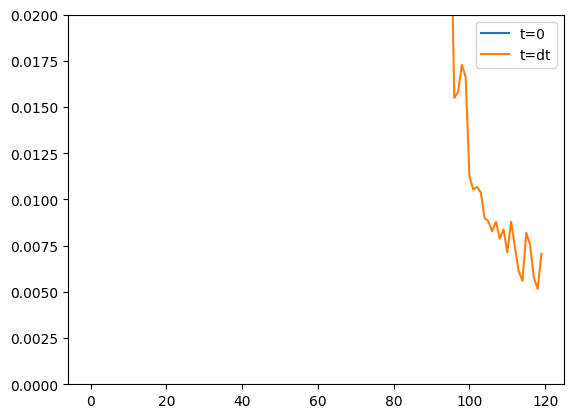

In [14]:
mean_over = 4
t0 = np.array([torch.mean(x).item() for x in loss_t_0])
t0_mean = t0[t0.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

t_dt = np.array(loss_t_dt)
t_dt_mean = t_dt[t_dt.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

plt.plot(t0_mean, label='t=0')
plt.plot(t_dt_mean, label='t=dt')
plt.legend()
plt.ylim(0.0,.02)
plt.show()

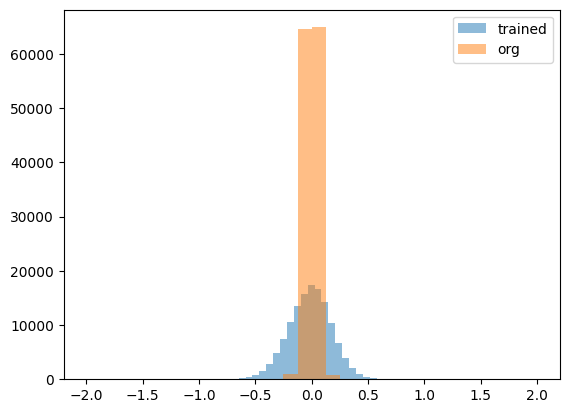

In [15]:
plt.hist(model.edge_params.detach().flatten().cpu(), bins=32, label='trained', alpha=0.5)
plt.hist((torch.randn(model.edge_params.shape)/20).flatten(), bins=32, label='org', alpha=0.5,range=(-2,2))
plt.legend()
plt.show()

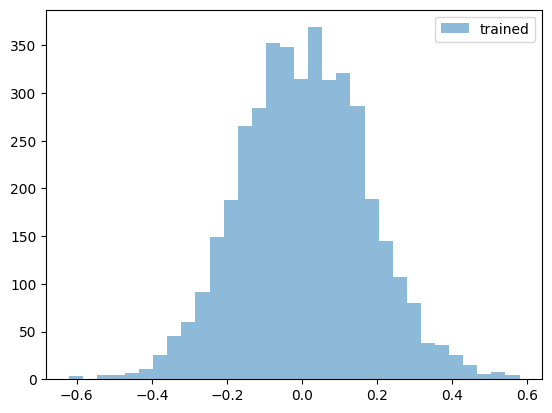

In [16]:
plt.hist([*model.l1.parameters()][-8].detach().flatten().cpu(), bins=32, label='trained', alpha=0.5)
plt.legend()
plt.show()

MSE: 1.442516565322876
MSE: 0.5464274883270264
MSE: 0.007766903378069401


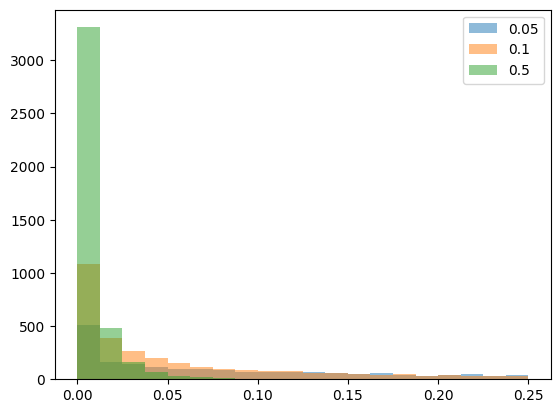

RMSE: 0.8777430057525635
RMSE: 0.4598843455314636
RMSE: 0.06865030527114868


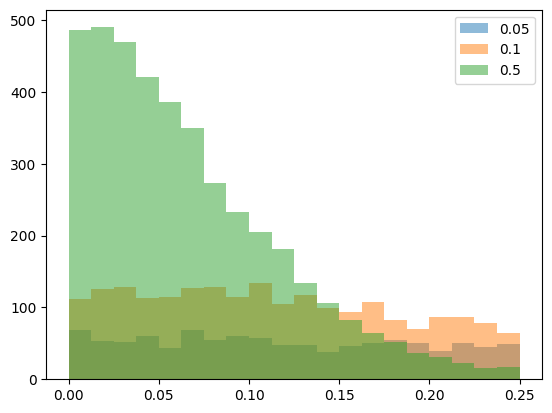

In [19]:
NUM_TEST_STEPS = 64
res_dict = {}
model.training_mode = False
with torch.no_grad():
    for inc_prob in [.05,.1,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(values,inclusion_prob=inc_prob).to(DEVICE)

            y_hat = model(
                sample
            )

            l_dt = ((sample.y[:,-3] - y_hat[:,-1])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,.25), alpha=0.5, label=str(label), bins=20)
    print(f"MSE: {np.mean(part_res)}")
plt.legend()
plt.show()

for label, part_res in res_dict.items():
    plt.hist(part_res**0.5,range=(0,.25), alpha=0.5, label=str(label), bins=20)
    print(f"RMSE: {np.mean(part_res**0.5)}")
plt.legend()
plt.show()

MSE: 0.49526119232177734
MSE: 0.49928998947143555
MSE: 0.48146259784698486
MSE: 0.4496460556983948


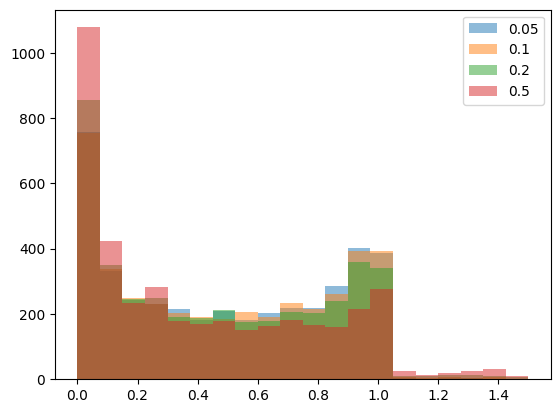

RMSE: 0.6296478509902954
RMSE: 0.6313860416412354
RMSE: 0.6119093894958496
RMSE: 0.5691847801208496


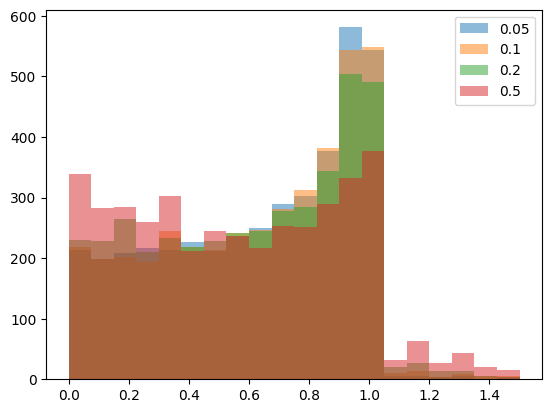

In [20]:
NUM_TEST_STEPS = 64
res_dict = {}

with torch.no_grad():
    for inc_prob in [.05,.1,.2,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(values,inclusion_prob=inc_prob)

            l_dt = ((sample.y[:,-3] - sample.x[:,-3])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
    print(f"MSE: {np.mean(part_res)}")
plt.legend()
plt.show()

for label, part_res in res_dict.items():
    plt.hist(part_res**0.5,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
    print(f"RMSE: {np.mean(part_res**0.5)}")
plt.legend()
plt.show()